# Interest-Conditioned Paper Summarization
### Does Personalization Hurt Faithfulness?

Steps:
- Fetch ArXiv papers across 5 CS categories + irrelevant out-of-domain papers
- Generate summaries conditioned on 5 user profiles
- Compare 5 models: gpt-4o, gpt-4o-mini, gpt-3.5-turbo, llama3.2:3b, mistral:7b
- Compare 3 prompt intensity levels: mild / moderate / aggressive
- Evaluate: BERTScore (faithfulness) + AlignScore (factual consistency)
- Analyze: relevant vs irrelevant domain papers


## 1. Setup & Imports

In [1]:
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import os, time, itertools, requests
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
import json as json_lib

from utils import (
    fetch_arxiv,
    build_prompt, build_prompt_level, PROMPT_LEVELS,
    compute_cosine_distances,
    load_or_score,
)


In [ ]:
# Remove the key since github not allowed
client  = OpenAI(api_key=None)
# used for profile alignment & cosine distance
encoder = SentenceTransformer("all-MiniLM-L6-v2")

# 5 models to compare: 3 OpenAI + 2 local (Ollama)
MODELS = [
    "gpt-4o",
    "gpt-4o-mini",
    "gpt-3.5-turbo",
    "llama3.2:3b",
    "mistral:7b",
]

# gpt-4o-mini is our default for the main experiments
MODEL = MODELS[1]
MODELS_ORDER = MODELS
os.makedirs("results", exist_ok=True)
print(f"Models: {MODELS}")
print(f"Default: {MODEL}")


Models: ['gpt-4o', 'gpt-4o-mini', 'gpt-3.5-turbo', 'llama3.2:3b', 'mistral:7b']
Default: gpt-4o-mini


## 2. Define Interest Profiles

In [3]:
# 5 reader profiles representing a range of backgrounds and expertise levels.
# The key contrast is technical (nlp_researcher, systems_engineer) vs non-technical (policy_maker).
PROFILES = [
    {
        "id": "nlp_researcher",
        "name": "NLP researcher",
        "desc": "Graduate student focused on language models, text generation, and NLP benchmarks",
    },
    {
        "id": "systems_engineer",
        "name": "Systems engineer",
        "desc": "Practitioner focused on scalability, latency, and production ML deployment",
    },
    {
        "id": "ml_beginner",
        "name": "ML beginner",
        "desc": "Undergraduate student learning machine learning fundamentals for the first time",
    },
    {
        "id": "cv_researcher",
        "name": "Computer vision researcher",
        "desc": "Researcher primarily working on image recognition and visual perception tasks",
    },
    {
        "id": "policy_maker",
        "name": "Policy maker",
        "desc": "Government official with no technical background interested in AI's societal impact, risks, and policy implications",
    },
]

for p in PROFILES:
    print(f"{p['name']}: {p['desc']}")


NLP researcher: Graduate student focused on language models, text generation, and NLP benchmarks
Systems engineer: Practitioner focused on scalability, latency, and production ML deployment
ML beginner: Undergraduate student learning machine learning fundamentals for the first time
Computer vision researcher: Researcher primarily working on image recognition and visual perception tasks
Policy maker: Government official with no technical background interested in AI's societal impact, risks, and policy implications


## 3. Fetch 20 ArXiv Papers per category

In [4]:
CATEGORIES = ["cs.LG", "cs.CL", "cs.IR", "cs.CV", "cs.DC"]
PAPERS_PER_CAT = 20
# fetch_arxiv() is defined in utils.py to fetch papers from arxiv


In [5]:
# load from cache if we've already fetched, otherwise fetch from arxiv
PAPERS_CSV = "results/papers.csv"
if os.path.exists(PAPERS_CSV):
    print(f"Loading papers from {PAPERS_CSV}...")
    papers_df = pd.read_csv(PAPERS_CSV)
    # convert to dict for easy access
    papers = papers_df.to_dict("records")
    print(f"Loaded {len(papers)} papers.")
else:
    print("CSV not found — fetching from ArXiv...")
    papers = fetch_arxiv(CATEGORIES, PAPERS_PER_CAT)
    papers_df = pd.DataFrame(papers)
    papers_df.to_csv(PAPERS_CSV, index=False)
    print(f"Saved {len(papers)} papers to {PAPERS_CSV}.")

papers_df[["arxiv_id", "category", "published", "title"]].head(5)


Loading papers from results/papers.csv...
Loaded 93 papers.


,arxiv_id,category,published,title
0,2604.25917v1,cs.LG,2026-04-28,Recursive Multi-Agent Systems
1,2604.25907v1,cs.LG,2026-04-28,How Fast Should a Model Commit to Supervision?...
2,2604.25904v1,cs.LG,2026-04-28,Teacher Forcing as Generalized Bayes: Optimiza...
3,2604.25903v1,cs.LG,2026-04-28,Carbon-Taxed Transformers: A Green Compression...
4,2604.25902v1,cs.LG,2026-04-28,Toward a Functional Geometric Algebra for Natu...


## 4. Generate Paper Summaries

In [6]:
# set time in between to avoid access issue
SLEEP_BETWEEN_CALLS = 1.0
# build_prompt() and build_prompt_level() are defined in utils.py


In [7]:
# Utility functions for Section 4
import requests as req

def call_ollama(model_name, prompt_text):
    # sends the prompt to a locally running Ollama server and returns the response
    # stream=False means we wait for the full response instead of getting it token by token
    resp = req.post(
        "http://localhost:11434/api/chat",
        json={
            "model": model_name,
            "messages": [{"role": "user", "content": prompt_text}],
            "stream": False,
            "options": {"temperature": 0}
        },
        # local models can be slow, give them up to 5 minutes
        timeout=300
    )
    data = resp.json()
    if "error" in data:
        raise ValueError(data["error"])
    return data["message"]["content"].strip()


def call_model(model_name, profile, abstract):
    # single entry point for all 5 models
    # routes to Ollama for local models, OpenAI API for the rest
    prompt_text = (
        "You are a helpful academic assistant.\n\n"
        + build_prompt(profile, abstract)
    )
    if model_name in ["llama3.2:3b", "mistral:7b"]:
        return call_ollama(model_name, prompt_text)
    else:
        resp = client.chat.completions.create(
            model=model_name,
            max_tokens=400,
            temperature=0,
            messages=[
                {"role": "system", "content": "You are a helpful academic assistant."},
                {"role": "user", "content": build_prompt(profile, abstract)},
            ],
        )
        return resp.choices[0].message.content.strip()


# Function used to generate interest conditioned summaries
def generate_conditioned_summaries(papers, profiles):
    rows  = []
    total = len(papers) * len(profiles)
    done  = 0
    for paper in papers:
        for profile in profiles:
            done += 1
            print(f"[{done:>3}/{total}] {paper['arxiv_id']} x {profile['id']}", end=" ... ", flush=True)
            try:
                resp = client.chat.completions.create(
                    # use tokens=400 since a paper summary is expected
                    # use temperature=0 to produce fixed outputs
                    model=MODEL, max_tokens=400, temperature=0,
                    messages=[
                        {"role": "system", "content": "You are a helpful academic assistant."},
                        {"role": "user",   "content": build_prompt(profile, paper["abstract"])},
                    ],
                )
                summary = resp.choices[0].message.content.strip()
                print("ok")
            except Exception as e:
                summary = ""
                print(f"ERROR: {e}")
            rows.append({
                "arxiv_id":     paper["arxiv_id"],
                "title":        paper["title"],
                "abstract":     paper["abstract"],
                "category":     paper["category"],
                "published":    paper["published"],
                "profile_id":   profile["id"],
                "profile_name": profile["name"],
                "summary":      summary,
            })
            time.sleep(SLEEP_BETWEEN_CALLS)
    return pd.DataFrame(rows)


# Similar to above function.
# no profile conditioning and used as the control group for faithfulness comparison
def generate_baseline_summaries(papers):
    rows  = []
    total = len(papers)
    for i, paper in enumerate(papers):
        print(f"[{i+1:>3}/{total}] {paper['arxiv_id']}", end=" ... ", flush=True)
        try:
            resp = client.chat.completions.create(
                # use tokens=400 since a paper summary is expected
                # use temperature=0 to produce fixed outputs
                model=MODEL, max_tokens=400, temperature=0,
                messages=[
                    {"role": "system", "content": "You are a helpful academic assistant."},
                    {"role": "user", "content": (
                        f"Paper abstract:\n{paper['abstract']}\n\n"
                        "Write a 3-sentence summary of this paper. "
                        "Be specific and faithful to what the paper actually says. "
                        "Do not add information not in the abstract."
                    )},
                ],
            )
            summary = resp.choices[0].message.content.strip()
            print("ok")
        except Exception as e:
            summary = ""
            print(f"ERROR: {e}")
        rows.append({
            "arxiv_id":     paper["arxiv_id"],
            "title":        paper["title"],
            "abstract":     paper["abstract"],
            "category":     paper["category"],
            "published":    paper["published"],
            "profile_id":   "baseline",
            "profile_name": "Baseline (no profile)",
            "summary":      summary,
        })
        time.sleep(SLEEP_BETWEEN_CALLS)
    return pd.DataFrame(rows)


# same prompt as conditioned summaries, but for out-of-domain papers
def generate_irrelevant_summaries(irr_papers, profiles):
    rows  = []
    total = len(irr_papers) * len(profiles)
    done  = 0
    for paper in irr_papers:
        for profile in profiles:
            done += 1
            print(f"[{done:>3}/{total}] {paper['arxiv_id']} x {profile['id']}", end=" ... ", flush=True)
            try:
                resp = client.chat.completions.create(
                    # use tokens=400 since a paper summary is expected
                    # use temperature=0 to produce fixed outputs
                    model=MODEL, max_tokens=400, temperature=0,
                    messages=[
                        {"role": "system", "content": "You are a helpful academic assistant."},
                        {"role": "user",   "content": build_prompt(profile, paper["abstract"])},
                    ],
                )
                summary = resp.choices[0].message.content.strip()
                print("ok")
            except Exception as e:
                summary = ""
                print(f"ERROR: {e}")
            rows.append({
                "arxiv_id":      paper["arxiv_id"],
                "title":         paper["title"],
                "abstract":      paper["abstract"],
                "category":      paper["category"],
                "published":     paper["published"],
                "profile_id":    profile["id"],
                "profile_name":  profile["name"],
                "summary":       summary,
                "is_irrelevant": True,
            })
            time.sleep(SLEEP_BETWEEN_CALLS)
    return pd.DataFrame(rows)


# stratified sample across categories, then generate at 3 intensity levels
def generate_prompt_level_summaries(papers, profiles, categories, n_per_cat):
    papers_df_local = pd.DataFrame(papers)
    # get a subset of paper from each category
    subset = (
        papers_df_local.groupby("category", group_keys=False)
        .apply(lambda g: g.head(n_per_cat))
        .to_dict("records")
    )
    print(f"Stratified subset: {len(subset)} papers — "
          f"{pd.DataFrame(subset)['category'].value_counts().to_dict()}")

    rows  = []
    total = len(subset) * len(profiles) * len(PROMPT_LEVELS)
    done  = 0
    for paper in subset:
        for profile in profiles:
            for level in PROMPT_LEVELS:
                done += 1
                print(f"[{done:>3}/{total}] {paper['arxiv_id']} x {profile['id']} x {level}", end=" ... ", flush=True)
                try:
                    resp = client.chat.completions.create(
                        # use tokens=400 since a paper summary is expected
                        # use temperature=0 to produce fixed outputs
                        model=MODEL, max_tokens=400, temperature=0,
                        messages=[
                            {"role": "system", "content": "You are a helpful academic assistant."},
                            {"role": "user",   "content": build_prompt_level(profile, paper["abstract"], level)},
                        ],
                    )
                    summary = resp.choices[0].message.content.strip()
                    print("ok")
                except Exception as e:
                    summary = ""
                    print(f"ERROR: {e}")
                rows.append({
                    "arxiv_id":     paper["arxiv_id"],
                    "title":        paper["title"],
                    "abstract":     paper["abstract"],
                    "category":     paper["category"],
                    "profile_id":   profile["id"],
                    "profile_name": profile["name"],
                    "prompt_level": level,
                    "summary":      summary,
                })
                time.sleep(SLEEP_BETWEEN_CALLS)
    return pd.DataFrame(rows)


# stratified sample of equal papers from each category for different model generations
def generate_multi_model_summaries(papers, models, profiles, categories, n_papers, sleep_sec):
    papers_df_local = pd.DataFrame(papers)
    # get a subset of paper from each category
    subset = (
        papers_df_local.groupby("category", group_keys=False)
        .apply(lambda g: g.head(n_papers // len(categories)))
        .to_dict("records")
    )
    print(f"Stratified subset: {len(subset)} papers — "
          f"{pd.DataFrame(subset)['category'].value_counts().to_dict()}")

    rows  = []
    total = len(subset) * len(profiles) * len(models)
    done  = 0

    for model_name in models:
        print(f"\n  Model: {model_name}")
        for paper in subset:
            for profile in profiles:
                done += 1
                print(f"[{done:>3}/{total}] {paper['arxiv_id']} x {profile['id']}", end=" ... ", flush=True)
                try:
                    summary = call_model(model_name, profile, paper["abstract"])
                    print("ok")
                except Exception as e:
                    summary = ""
                    print(f"ERROR: {e}")

                rows.append({
                    "model":        model_name,
                    "arxiv_id":     paper["arxiv_id"],
                    "title":        paper["title"],
                    "abstract":     paper["abstract"],
                    "category":     paper["category"],
                    "profile_id":   profile["id"],
                    "profile_name": profile["name"],
                    "summary":      summary,
                })
                # no sleep for local Ollama models since there is no rate limit
                if model_name not in ["llama3.2:3b", "mistral:7b"]:
                    time.sleep(sleep_sec)

    return pd.DataFrame(rows)


print("Helper functions ready: call_model, generate_*")

Helper functions ready: call_model, generate_*


##### Generate summaries conditioned on user profiles

In [8]:
SUMMARIES_CSV = "results/summaries_raw.csv"

# check for if summaries have been generated
# If yes, load the summaries df
# If no, call the corresponding generation function and generate summaries
if os.path.exists(SUMMARIES_CSV):
    print(f"Loading summaries from {SUMMARIES_CSV}...")
    df = pd.read_csv(SUMMARIES_CSV)
    print(f"Loaded {len(df)} rows.")
else:
    df = generate_conditioned_summaries(papers, PROFILES)
    df.to_csv(SUMMARIES_CSV, index=False)
    print(f"Saved {len(df)} rows.")

df.head(5)


Loading summaries from results/summaries_raw.csv...
Loaded 465 rows.


,arxiv_id,title,abstract,category,published,profile_id,profile_name,summary
0,2604.25917v1,Recursive Multi-Agent Systems,Recursive or looped language models have recen...,cs.LG,2026-04-28,nlp_researcher,NLP researcher,"The paper introduces RecursiveMAS, a novel rec..."
1,2604.25917v1,Recursive Multi-Agent Systems,Recursive or looped language models have recen...,cs.LG,2026-04-28,systems_engineer,Systems engineer,"The paper introduces RecursiveMAS, a recursive..."
2,2604.25917v1,Recursive Multi-Agent Systems,Recursive or looped language models have recen...,cs.LG,2026-04-28,ml_beginner,ML beginner,"This paper introduces RecursiveMAS, a new fram..."
3,2604.25917v1,Recursive Multi-Agent Systems,Recursive or looped language models have recen...,cs.LG,2026-04-28,cv_researcher,Computer vision researcher,"The paper introduces RecursiveMAS, a recursive..."
4,2604.25917v1,Recursive Multi-Agent Systems,Recursive or looped language models have recen...,cs.LG,2026-04-28,policy_maker,Policy maker,"This paper introduces RecursiveMAS, a novel fr..."


##### Generate baseline summaries without conditioning on user profiles

In [9]:
BASELINE_CSV = "results/baseline_summaries.csv"

# check for if summaries have been generated
# If yes, load the summaries df
# If no, call the corresponding generation function and generate summaries
if os.path.exists(BASELINE_CSV):
    print(f"Loading baseline from {BASELINE_CSV}...")
    baseline_df = pd.read_csv(BASELINE_CSV)
    print(f"Loaded {len(baseline_df)} rows.")
else:
    baseline_df = generate_baseline_summaries(papers)
    baseline_df.to_csv(BASELINE_CSV, index=False)
    print(f"Saved {len(baseline_df)} rows.")

baseline_df[["arxiv_id", "category", "summary"]].head(5)


Loading baseline from results/baseline_summaries.csv...
Loaded 93 rows.


,arxiv_id,category,summary
0,2604.25917v1,cs.LG,"The paper introduces RecursiveMAS, a recursive..."
1,2604.25907v1,cs.LG,This paper addresses the issue of cold-start s...
2,2604.25904v1,cs.LG,The paper investigates the effects of identity...
3,2604.25903v1,cs.LG,This paper addresses the unsustainable computa...
4,2604.25902v1,cs.LG,"This paper argues that geometric algebra (GA),..."


In [10]:
# Quick check: same paper, different profiles
sample_id = df["arxiv_id"].iloc[0]
print(f"Paper: {df[df['arxiv_id']==sample_id]['title'].iloc[0]}\n")
for _, row in df[df["arxiv_id"]==sample_id][["profile_name","summary"]].iterrows():
    print(f"── {row['profile_name']} ──")
    print(row["summary"])
    print()

Paper: Recursive Multi-Agent Systems

── NLP researcher ──
The paper introduces RecursiveMAS, a novel recursive multi-agent framework that enhances agent collaboration by treating the entire system as a unified latent-space recursive computation. By employing a lightweight RecursiveLink module, RecursiveMAS facilitates in-distribution latent thought generation and cross-agent latent state transfer, optimizing the framework through an inner-outer loop learning algorithm for co-optimization. Empirical evaluations across various benchmarks demonstrate that RecursiveMAS achieves an average accuracy improvement of 8.3%, alongside significant gains in inference speed and token usage efficiency compared to existing models.

── Systems engineer ──
The paper introduces RecursiveMAS, a recursive multi-agent framework that enhances collaboration among heterogeneous agents by utilizing a unified latent-space recursive computation. This approach not only improves scalability through iterative model

### 4b. Fetch Irrelevant Papers (Out-of-Domain)

In [11]:
# Papers from domains unrelated to all 5 profiles
# Hypothesis: model has to work harder to find an angle
# and since there isn't one -> more hallucination

# Fetch 20 per category (60 total)
IRRELEVANT_CATEGORIES = ["math.ST", "econ.GN", "q-bio.NC"]
IRRELEVANT_PER_CAT = 20

IRR_PAPERS_CSV = "results/irrelevant_papers.csv"
TARGET_IRR = IRRELEVANT_PER_CAT * len(IRRELEVANT_CATEGORIES)

# check for if summaries have been generated
# If yes, load the summaries df
# If no, call the corresponding generation function and generate summaries
if os.path.exists(IRR_PAPERS_CSV):
    print(f"Loading irrelevant papers from {IRR_PAPERS_CSV}...")
    irr_papers_df = pd.read_csv(IRR_PAPERS_CSV)
    irr_papers = irr_papers_df.to_dict("records")
    print(f"Loaded {len(irr_papers)} irrelevant papers.")

else:
    print("Fetching irrelevant papers from ArXiv...")
    irr_papers = fetch_arxiv(IRRELEVANT_CATEGORIES, IRRELEVANT_PER_CAT)
    irr_papers_df = pd.DataFrame(irr_papers)
    irr_papers_df["is_irrelevant"] = True
    irr_papers_df.to_csv(IRR_PAPERS_CSV, index=False)
    print(f"Saved {len(irr_papers)} irrelevant papers.")

papers_df["is_irrelevant"] = False
print(f"Irrelevant papers total: {len(irr_papers)}  (relevant: {len(papers)})")
irr_papers_df[["arxiv_id", "category", "title"]].head(5)

Loading irrelevant papers from results/irrelevant_papers.csv...
Loaded 60 irrelevant papers.
Irrelevant papers total: 60  (relevant: 93)


,arxiv_id,category,title
0,2605.06521v1,math.ST,Time-sensitive anytime-valid testing
1,2605.06479v1,math.ST,Risk-Controlled Post-Processing of Decision Po...
2,2605.06417v1,math.ST,Minimax estimation of Functional Principal Com...
3,2605.06386v1,math.ST,Covariate Balancing and Riesz Regression Shoul...
4,2605.06375v1,math.ST,A Unified Pair-GRPO Family: From Implicit to E...


##### Generate summaries for papers from irrelevant categories conditioned on user profiles

In [12]:
IRR_SUMMARIES_CSV = "results/irrelevant_summaries.csv"

# check for if summaries have been generated
# If yes, load the summaries df
# If no, call the corresponding generation function and generate summaries
if os.path.exists(IRR_SUMMARIES_CSV):
    print(f"Loading irrelevant summaries from {IRR_SUMMARIES_CSV}...")
    irr_df = pd.read_csv(IRR_SUMMARIES_CSV)
    print(f"Loaded {len(irr_df)} rows ({irr_df['arxiv_id'].nunique()} papers).")
else:
    irr_df = generate_irrelevant_summaries(irr_papers, PROFILES)
    irr_df.to_csv(IRR_SUMMARIES_CSV, index=False)
    print(f"Saved {len(irr_df)} rows.")

irr_df.head(5)


Loading irrelevant summaries from results/irrelevant_summaries.csv...
Loaded 300 rows (60 papers).


,arxiv_id,title,abstract,category,published,profile_id,profile_name,summary,is_irrelevant
0,2605.06521v1,Time-sensitive anytime-valid testing,Anytime-valid tests allow evidence to be check...,math.ST,2026-05-07,nlp_researcher,NLP researcher,This paper introduces a time-sensitive testing...,True
1,2605.06521v1,Time-sensitive anytime-valid testing,Anytime-valid tests allow evidence to be check...,math.ST,2026-05-07,systems_engineer,Systems engineer,This paper presents a time-sensitive testing-b...,True
2,2605.06521v1,Time-sensitive anytime-valid testing,Anytime-valid tests allow evidence to be check...,math.ST,2026-05-07,ml_beginner,ML beginner,This paper introduces a new approach to statis...,True
3,2605.06521v1,Time-sensitive anytime-valid testing,Anytime-valid tests allow evidence to be check...,math.ST,2026-05-07,cv_researcher,Computer vision researcher,This paper introduces a time-sensitive testing...,True
4,2605.06521v1,Time-sensitive anytime-valid testing,Anytime-valid tests allow evidence to be check...,math.ST,2026-05-07,policy_maker,Policy maker,This paper introduces a novel framework for te...,True


### 4c. Prompt Strength Experiment

In [13]:
# prompt intensity experiment: does more aggressive personalization hurt faithfulness?
# mild keeps the faithfulness constraint, aggressive removes it entirely
# build_prompt_level() and PROMPT_LEVELS are defined in utils.py
print("Prompt levels:")
for level, template in PROMPT_LEVELS.items():
    print(f"{level}: {template}")

Prompt levels:
mild: Write a 3-sentence summary of this paper for a {name}. Be faithful to what the abstract says.
moderate: Write a 3-sentence summary of this paper tailored to a {name} — {desc}. Highlight aspects most relevant to their profile. Be faithful to what the paper actually says. Do not add information not in the abstract.
aggressive: Write a 3-sentence summary of this paper SPECIFICALLY for a {name} — {desc}. Heavily emphasize what matters most to this reader. Actively reinterpret the paper through their lens and background. Use language and framing that speaks directly to their expertise and concerns.


##### Generate summaries conditioned on user profiles at different prompt intensities

In [14]:
# stratified sample: 6 papers per CS category = 30 papers total
PROMPT_CSV = "results/prompt_level_summaries.csv"
PROMPT_N_PER_CAT = 6

if os.path.exists(PROMPT_CSV):
    print(f"Loading prompt-level summaries from {PROMPT_CSV}...")
    prompt_df = pd.read_csv(PROMPT_CSV)
    print(f"Loaded {len(prompt_df)} rows ({prompt_df['arxiv_id'].nunique()} papers).")
else:
    prompt_df = generate_prompt_level_summaries(papers, PROFILES, CATEGORIES, PROMPT_N_PER_CAT)
    prompt_df.to_csv(PROMPT_CSV, index=False)
    print(f"Saved {len(prompt_df)} rows.")

prompt_df.head(5)


Loading prompt-level summaries from results/prompt_level_summaries.csv...
Loaded 450 rows (30 papers).


,arxiv_id,title,abstract,category,profile_id,profile_name,prompt_level,summary
0,2604.25914v1,DV-World: Benchmarking Data Visualization Agen...,Real-world data visualization (DV) requires na...,cs.CL,nlp_researcher,NLP researcher,mild,"The paper introduces DV-World, a benchmark com..."
1,2604.25914v1,DV-World: Benchmarking Data Visualization Agen...,Real-world data visualization (DV) requires na...,cs.CL,nlp_researcher,NLP researcher,moderate,"The paper introduces DV-World, a benchmark com..."
2,2604.25914v1,DV-World: Benchmarking Data Visualization Agen...,Real-world data visualization (DV) requires na...,cs.CL,nlp_researcher,NLP researcher,aggressive,"The paper introduces DV-World, a comprehensive..."
3,2604.25914v1,DV-World: Benchmarking Data Visualization Agen...,Real-world data visualization (DV) requires na...,cs.CL,systems_engineer,Systems engineer,mild,"The paper introduces DV-World, a benchmark com..."
4,2604.25914v1,DV-World: Benchmarking Data Visualization Agen...,Real-world data visualization (DV) requires na...,cs.CL,systems_engineer,Systems engineer,moderate,"The paper introduces DV-World, a benchmark com..."


### 4d. Multi-Model Comparison

The main experiment uses only gpt-4o-mini. This section tests whether the faithfulness drop is consistent across different models, or specific to one.

We run the same personalized summarization task on 5 models:
- **gpt-4o, gpt-4o-mini, gpt-3.5-turbo** — OpenAI API
- **llama3.2:3b, mistral:7b** — local models via Ollama

In [15]:
MODEL_N_PAPERS = 30
MODEL_CSV = "results/multi_model_summaries.csv"

if os.path.exists(MODEL_CSV):
    print(f"Loading multi-model summaries from {MODEL_CSV}...")
    model_df = pd.read_csv(MODEL_CSV)
    print(f"Loaded {len(model_df)} rows ({model_df['arxiv_id'].nunique()} papers).")
else:
    print(f"Generating summaries for {MODEL_N_PAPERS} papers across {len(MODELS)} models...")
    model_df = generate_multi_model_summaries(
        papers, MODELS, PROFILES, CATEGORIES, MODEL_N_PAPERS, SLEEP_BETWEEN_CALLS
    )
    model_df.to_csv(MODEL_CSV, index=False)
    print(f"Saved {len(model_df)} rows ({model_df['arxiv_id'].nunique()} papers).")

model_df.head(5)


Loading multi-model summaries from results/multi_model_summaries.csv...
Loaded 750 rows (30 papers).


,model,arxiv_id,title,abstract,category,profile_id,profile_name,summary
0,gpt-4o,2604.25914v1,DV-World: Benchmarking Data Visualization Agen...,Real-world data visualization (DV) requires na...,cs.CL,nlp_researcher,NLP researcher,"The paper introduces DV-World, a benchmark com..."
1,gpt-4o,2604.25914v1,DV-World: Benchmarking Data Visualization Agen...,Real-world data visualization (DV) requires na...,cs.CL,systems_engineer,Systems engineer,"The paper introduces DV-World, a benchmark of ..."
2,gpt-4o,2604.25914v1,DV-World: Benchmarking Data Visualization Agen...,Real-world data visualization (DV) requires na...,cs.CL,ml_beginner,ML beginner,"The paper introduces DV-World, a benchmark wit..."
3,gpt-4o,2604.25914v1,DV-World: Benchmarking Data Visualization Agen...,Real-world data visualization (DV) requires na...,cs.CL,cv_researcher,Computer vision researcher,"The paper introduces DV-World, a benchmark des..."
4,gpt-4o,2604.25914v1,DV-World: Benchmarking Data Visualization Agen...,Real-world data visualization (DV) requires na...,cs.CL,policy_maker,Policy maker,"The paper introduces DV-World, a benchmark des..."


## 5. Evaluation Metrics

### 5a. Faithfulness — BERTScore F1

**What:** Measures how semantically faithful each personalized summary is to the original abstract.

**Groups compared:** The 465 conditioned summaries (93 papers x 5 profiles), grouped by profile. Each summary is scored against the abstract it was generated from.

**How it works:** BERTScore embeds both texts using DistilBERT, then computes token-level cosine similarity. The F1 score captures both precision (does the summary stay on topic?) and recall (does it cover the abstract?).

**What to look for:** Profiles like policy_maker and ml_beginner are expected to score lower since the model has to simplify or reframe content more aggressively.

In [16]:
# BERTScore measures how semantically similar two pieces of text are using BERT embeddings.
valid = df["summary"].str.len() > 0
summaries = df.loc[valid, "summary"].tolist()
abstracts = df.loc[valid, "abstract"].tolist()

print("Computing BERTScore...")
_, _, F1 = bert_score(summaries, abstracts, lang="en", model_type="distilbert-base-uncased", verbose=False)

df.loc[valid, "bertscore_f1"] = F1.tolist()

print("\nMean BERTScore F1 by profile:")
print(df.groupby("profile_name")["bertscore_f1"].agg(["mean","std"]).round(4))


Computing BERTScore...

Mean BERTScore F1 by profile:
                              mean     std
profile_name                              
Computer vision researcher  0.8423  0.0231
ML beginner                 0.8040  0.0290
NLP researcher              0.8488  0.0225
Policy maker                0.7983  0.0306
Systems engineer            0.8376  0.0226


### 5b. Personalization — Pairwise Cosine Distance

**What:** Measures how different the summaries are from each other across profiles, for the same paper. But cosine distance is not a perfect measure for personalization since distance can't always infer good personalization. So this is just a reference.

**Groups compared:** All 10 pairwise combinations of the 5 profiles, computed per paper then averaged.

**How it works:** Embed all 5 summaries for the same paper, then compute 1 - cosine_similarity for each pair. Larger distance = more different outputs

**What to look for:** Distant pairs like `nlp_researcher` vs `policy_maker` should have larger distances than similar pairs like `nlp_researcher` vs `systems_engineer`. Near zero distances would mean personalization is not working (content are very similar).

In [17]:
# pairwise cosine distance between summaries of the same paper across profiles
# larger distance = more different summaries = personalization is changing the output
print("Encoding summaries and computing pairwise distances...")
records = compute_cosine_distances(df, encoder)
dist_df = pd.DataFrame(records)
dist_df.to_csv("results/cosine_distances.csv", index=False)

print("Mean cosine distance by profile pair:")
print(dist_df.groupby(["profile_a","profile_b"])["cosine_dist"].agg(["mean","std"]).round(4))


Encoding summaries and computing pairwise distances...
Mean cosine distance by profile pair:
                                     mean     std
profile_a        profile_b                       
cv_researcher    policy_maker      0.2315  0.0821
ml_beginner      cv_researcher     0.1876  0.0825
                 policy_maker      0.1615  0.0652
nlp_researcher   cv_researcher     0.1092  0.0712
                 ml_beginner       0.1805  0.0746
                 policy_maker      0.2254  0.0836
                 systems_engineer  0.1127  0.0549
systems_engineer cv_researcher     0.1263  0.0662
                 ml_beginner       0.1878  0.0797
                 policy_maker      0.2211  0.0786


### 5c. Profile Alignment Accuracy

**What:** Checks whether each summary is recognizably aligned with the profile it was written for.

**Groups compared:** All 465 conditioned summaries (93 papers x 5 profiles). Each summary is treated as a query and matched against the 5 profile descriptions using embeddings.

**How it works:** Embed each summary and all 5 profile descriptions with the same sentence encoder. For each summary, find the most similar profile description by cosine similarity. If the best match is the intended profile, it counts as correct.

**What to look for:** Overall accuracy above 0.20 (random baseline for 5 classes) means the personalization is linguistically detectable. Per-profile breakdown shows which profiles produce the most distinctly recognizable summaries.

In [18]:
# for each summary, ask: which profile description does this sound most like?
# check if the answer matches the profile it was actually written for

profile_texts = [p["desc"] for p in PROFILES]
profile_ids = [p["id"]   for p in PROFILES]
profile_names = [p["name"] for p in PROFILES]

print("Encoding profile descriptions...")
profile_embeddings = encoder.encode(profile_texts, show_progress_bar=False)

print("Encoding summaries...")
valid_df = df[df["summary"].str.len() > 0].reset_index(drop=True)
summary_embeddings = encoder.encode(valid_df["summary"].tolist(), show_progress_bar=True)

alignment_rows = []
# loop through the df to compute cosine similarity to see the prob of corrsponding
# summary is chosen
for i, row in valid_df.iterrows():
    emb = summary_embeddings[i].reshape(1, -1)
    sims = cosine_similarity(emb, profile_embeddings)[0]
    best_profile = profile_ids[int(np.argmax(sims))]
    is_correct = (best_profile == row["profile_id"])
    entry = {
        "arxiv_id":        row["arxiv_id"],
        "profile_id":      row["profile_id"],
        "profile_name":    row["profile_name"],
        "own_profile_sim": float(sims[profile_ids.index(row["profile_id"])]),
        "best_match":      best_profile,
        "is_correct":      is_correct,
    }
    for pid, sim in zip(profile_ids, sims):
        entry[f"sim_{pid}"] = float(sim)
    alignment_rows.append(entry)

align_df = pd.DataFrame(alignment_rows)
align_df.to_csv("results/profile_alignment.csv", index=False)

accuracy = align_df["is_correct"].mean()
print(f"Profile alignment accuracy: {accuracy:.3f}  (random baseline: 0.20)")
print("Per-profile accuracy:")
print(align_df.groupby("profile_name")["is_correct"].mean().round(3))


Encoding profile descriptions...
Encoding summaries...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Profile alignment accuracy: 0.445  (random baseline: 0.20)
Per-profile accuracy:
profile_name
Computer vision researcher    0.301
ML beginner                   0.333
NLP researcher                0.581
Policy maker                  0.570
Systems engineer              0.441
Name: is_correct, dtype: float64


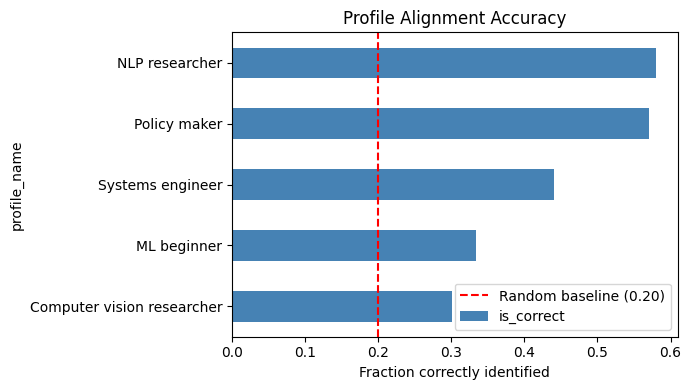

In [19]:
# Plot profile alignment accuracy
fig, ax = plt.subplots(figsize=(7, 4))

acc = align_df.groupby("profile_name")["is_correct"].mean().sort_values()
acc.plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(0.20, color="red", linestyle="--", label="Random baseline (0.20)")
ax.set_title("Profile Alignment Accuracy")
ax.set_xlabel("Fraction correctly identified")
ax.legend()

plt.tight_layout()
plt.savefig("results/profile_alignment.png", dpi=150)
plt.show()


### 5d. Personalization Quality — LLM Pairwise Judge

**What:** Asks GPT to judge which of two summaries is better suited for a target reader, without knowing which summary was written for that profile.

**Groups compared:** Two conditions per (paper, profile) pair --
- **Hardest comparison:** compared against the most similar profile (upper bound difficulty)
- **Random comparison:** compared against a randomly chosen other profile (lower bound difficulty)

**How it works:** 930 comparisons total (93 papers x 5 profiles x 2 conditions). A/B position is randomized each time to remove LLM position bias. Win rate = fraction of times the intended summary wins.

**What to look for:** Win rate significantly above 0.50 means personalization produces summaries that are distinguishable as better-suited even to a blind judge. Comparing hardest vs random comparison gives a difficulty range.

In [20]:
import json as json_lib, random

JUDGE_CSV      = "results/llm_judge_pairwise.csv"
JUDGE_N_PAPERS = 93 

# given two summaries and a reader profile, ask GPT which summary is better suited
# the judge doesn't know which was written for the target profile — pure content judgment
def pairwise_judge(profile_name, profile_desc, abstract, summary_a, summary_b):
    sep    = "\n\n"
    prompt = sep.join([
        "You are evaluating which of two paper summaries is better suited for a specific reader.",
        "Reader profile: " + profile_name + " - " + profile_desc,
        "Paper abstract:\n" + abstract,
        "Summary A:\n" + summary_a,
        "Summary B:\n" + summary_b,
        ("Which summary is better suited for this reader's background and interests? "
         "Consider: relevance of emphasis, appropriateness of language and depth. "
         'Respond ONLY in JSON: {"winner": "A" or "B" or "tie", "reason": "<one sentence>"}'),
    ])
    resp = client.chat.completions.create(
        model=MODEL, temperature=0, max_tokens=100,
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
    )
    return json_lib.loads(resp.choices[0].message.content)

print("pairwise_judge() ready.")


pairwise_judge() ready.


In [21]:
# build two comparison pairs per (paper, profile):
#   hardest: vs the most similar profile — tests if personalization is detectable under pressure
#   random:  vs a random other profile  — easy baseline, lower bound
def run_pairwise_comparisons(df, profiles, hardest_comparison, n_papers, rng):
    subset_ids = df["arxiv_id"].unique()[:n_papers]
    all_rows = df[df["arxiv_id"].isin(subset_ids) & (df["summary"].str.len() > 0)]

    comparisons = []
    for arxiv_id in subset_ids:
        paper_rows = all_rows[all_rows["arxiv_id"] == arxiv_id]
        pid_to_summary = dict(zip(paper_rows["profile_id"], paper_rows["summary"]))
        abstract = paper_rows["abstract"].iloc[0]

        for profile in profiles:
            pid_a = profile["id"]
            if pid_a not in pid_to_summary:
                continue

            # hardest: most similar profile by embedding
            pid_hard = hardest_comparison[pid_a]
            if pid_hard in pid_to_summary:
                comparisons.append({
                    "arxiv_id": arxiv_id, "abstract": abstract,
                    "target_profile_id": pid_a, "target_profile_name": profile["name"],
                    "target_profile_desc": profile["desc"],
                    "comparison_profile_id": pid_hard, "comparison_type": "hardest",
                    "summary_intended":    pid_to_summary[pid_a],
                    "comparison_summary":  pid_to_summary[pid_hard],
                })

            # random: any other profile
            other_ids = [p["id"] for p in profiles if p["id"] != pid_a and p["id"] in pid_to_summary]
            pid_random = rng.choice(other_ids)
            comparisons.append({
                "arxiv_id": arxiv_id, "abstract": abstract,
                "target_profile_id": pid_a, "target_profile_name": profile["name"],
                "target_profile_desc": profile["desc"],
                "comparison_profile_id": pid_random, "comparison_type": "random",
                "summary_intended": pid_to_summary[pid_a],
                "comparison_summary":  pid_to_summary[pid_random],
            })

    total = len(comparisons)
    judge_rows = []
    print(f"Running {total} comparisons ({n_papers} papers x {len(profiles)} profiles x 2 conditions)...")

    for i, cmp in enumerate(comparisons):
        # randomize A/B position so the judge can't win by always picking the first option
        intended_is_a = rng.random() < 0.5
        sum_a = cmp["summary_intended"]   if intended_is_a else cmp["comparison_summary"]
        sum_b = cmp["comparison_summary"] if intended_is_a else cmp["summary_intended"]

        aid, tpid, fpid = cmp["arxiv_id"], cmp["target_profile_id"], cmp["comparison_profile_id"]
        print(f"[{i+1:>4}/{total}] {aid} | {tpid} vs {fpid} [{cmp['comparison_type']}]", end=" ... ", flush=True)

        result = {}
        try:
            result  = pairwise_judge(
                cmp["target_profile_name"], cmp["target_profile_desc"],
                cmp["abstract"], sum_a, sum_b
            )
            winner  = result.get("winner", "").strip().upper()
            # correct = intended summary won, regardless of whether it was A or B
            correct = (winner == "A") if intended_is_a else (winner == "B")
            print(f"winner={winner} ({'correct' if correct else 'wrong'})")
        except Exception as e:
            winner, correct = "", False
            print(f"ERROR: {e}")

        judge_rows.append({
            "arxiv_id":             cmp["arxiv_id"],
            "target_profile_id":    cmp["target_profile_id"],
            "target_profile_name":  cmp["target_profile_name"],
            "comparison_profile_id":cmp["comparison_profile_id"],
            "comparison_type":      cmp["comparison_type"],
            "intended_is_a":        intended_is_a,
            "winner":               winner,
            "intended_won":         correct,
            "reason":               result.get("reason", ""),
        })
        time.sleep(SLEEP_BETWEEN_CALLS)

    return pd.DataFrame(judge_rows)

print("run_pairwise_comparisons() ready.")


run_pairwise_comparisons() ready.


In [22]:
# for each profile, find the most similar other profile by embedding similarity
# this becomes the "hardest comparison"
profile_descs = [p["desc"] for p in PROFILES]
profile_ids = [p["id"]   for p in PROFILES]
desc_embs = encoder.encode(profile_descs, show_progress_bar=False)
desc_sims = cosine_similarity(desc_embs)   # 5x5 similarity matrix

hardest_comparison = {}
for i, pid in enumerate(profile_ids):
    sims_i = desc_sims[i].copy()
    sims_i[i] = -1   # exclude self
    hardest_comparison[pid] = profile_ids[int(sims_i.argmax())]

print("Hardest comparison per profile (most similar by description embedding):")
for pid, comp in hardest_comparison.items():
    print(f"  {pid:<22} -> {comp}")


Hardest comparison per profile (most similar by description embedding):
  nlp_researcher         -> ml_beginner
  systems_engineer       -> ml_beginner
  ml_beginner            -> nlp_researcher
  cv_researcher          -> ml_beginner
  policy_maker           -> cv_researcher


In [23]:
# load existing results or run all comparisons from scratch
if os.path.exists(JUDGE_CSV):
    judge_df = pd.read_csv(JUDGE_CSV)
    print(f"Loaded {JUDGE_CSV} ({len(judge_df)} rows, {judge_df['arxiv_id'].nunique()} papers).")
else:
    # fixed seed for reproducibility
    rng = random.Random(42)
    judge_df = run_pairwise_comparisons(df, PROFILES, hardest_comparison, JUDGE_N_PAPERS, rng)
    judge_df.to_csv(JUDGE_CSV, index=False)
    print(f"Saved {len(judge_df)} rows to {JUDGE_CSV}.")


Loaded results/llm_judge_pairwise.csv (930 rows, 93 papers).


In [24]:
# win rate = fraction of times the intended profile's summary is judged as better
# two conditions give a range: random (easy) and hardest (hard)
print("Overall win rate by condition (random baseline: 0.50):")
print(judge_df.groupby("comparison_type")["intended_won"].agg(["mean", "count"]).round(3))

print("\nWin rate by profile x comparison type:")
wr = judge_df.groupby(["target_profile_name", "comparison_type"])["intended_won"].mean().unstack()
wr.columns.name = None
print(wr.round(3))


Overall win rate by condition (random baseline: 0.50):
                  mean  count
comparison_type              
hardest          0.996    465
random           0.951    465

Win rate by profile x comparison type:
                            hardest  random
target_profile_name                        
Computer vision researcher    1.000   0.828
ML beginner                   0.978   0.978
NLP researcher                1.000   0.957
Policy maker                  1.000   1.000
Systems engineer              1.000   0.989


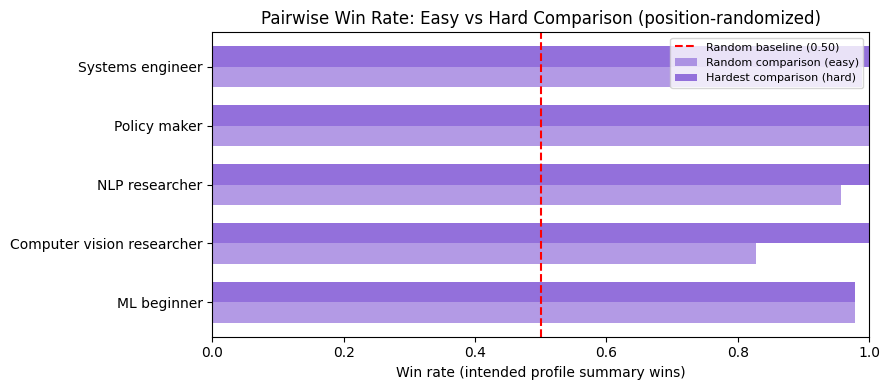

Saved results/llm_judge_pairwise.png


In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
wr_plot  = wr.sort_values("hardest")[["random", "hardest"]]
x, width = range(len(wr_plot)), 0.35

# lighter bar = random (easy), darker bar = hardest (hard)
ax.barh([i - width/2 for i in x], wr_plot["random"],  height=width, label="Random comparison (easy)",  color="mediumpurple", alpha=0.7)
ax.barh([i + width/2 for i in x], wr_plot["hardest"], height=width, label="Hardest comparison (hard)", color="mediumpurple")
ax.set_yticks(list(x))
ax.set_yticklabels(wr_plot.index)
ax.axvline(0.5, color="red", linestyle="--", label="Random baseline (0.50)")
ax.set_xlim(0, 1)
ax.set_title("Pairwise Win Rate: Easy vs Hard Comparison (position-randomized)")
ax.set_xlabel("Win rate (intended profile summary wins)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("results/llm_judge_pairwise.png", dpi=150)
plt.show()
print("Saved results/llm_judge_pairwise.png")


## 6. Extended Evaluation

### 6a. BERTScore — Prompt Levels

**What:** Does stronger personalization pressure reduce how faithful the summary is to the abstract?

**Groups compared:** 3 prompt intensity levels (mild / moderate / aggressive) x 5 profiles x 30 stratified papers = 450 summaries.

**How:** BERTScore computed for each summary against the original abstract.

**What to look for:** Decreasing BERTScore from mild to aggressive confirms that stronger personalization instructions trade off faithfulness for reader relevance.

In [26]:
# compute BERTScore for each summary vs its abstract
valid_prompt = prompt_df[prompt_df["summary"].str.len() > 0].reset_index(drop=True)

print("Computing BERTScore for prompt levels...")
_, _, F1_p = bert_score(
    valid_prompt["summary"].tolist(),
    valid_prompt["abstract"].tolist(),
    lang="en", model_type="distilbert-base-uncased", verbose=False
)
valid_prompt["bertscore_f1"] = F1_p.tolist()
valid_prompt.to_csv("results/prompt_level_evaluated.csv", index=False)

order = ["mild", "moderate", "aggressive"]
print("\nMean BERTScore F1 by prompt level:")
print(valid_prompt.groupby("prompt_level")["bertscore_f1"].agg(["mean","std"]).reindex(order).round(4))

print("\nMean BERTScore F1 by prompt level x profile:")
print(valid_prompt.pivot_table(
    values="bertscore_f1", index="profile_name",
    columns="prompt_level", aggfunc="mean"
)[order].round(4))


Computing BERTScore for prompt levels...

Mean BERTScore F1 by prompt level:
                mean     std
prompt_level                
mild          0.8239  0.0358
moderate      0.8151  0.0361
aggressive    0.7944  0.0362

Mean BERTScore F1 by prompt level x profile:
prompt_level                  mild  moderate  aggressive
profile_name                                            
Computer vision researcher  0.8461    0.8297      0.8056
ML beginner                 0.7919    0.7922      0.7765
NLP researcher              0.8474    0.8410      0.8198
Policy maker                0.7935    0.7807      0.7589
Systems engineer            0.8408    0.8318      0.8113


C:\Users\baodu\AppData\Local\Temp\ipykernel_43320\2835587153.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_prompt, x="prompt_level", y="bertscore_f1",


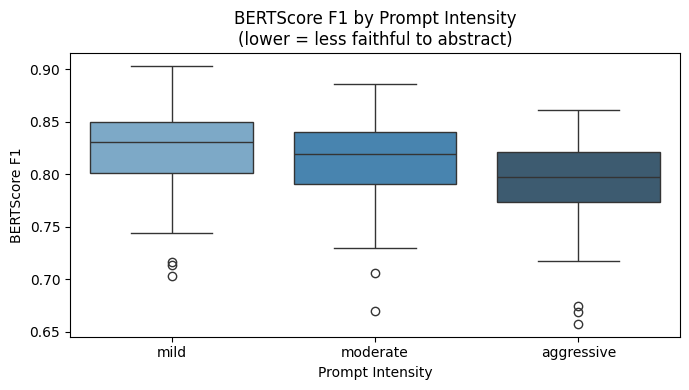

Saved results/prompt_level_bertscore.png


In [27]:
# Plot BERTScore for different prompt levels
fig, ax = plt.subplots(figsize=(7, 4))
order = ["mild", "moderate", "aggressive"]
sns.boxplot(data=valid_prompt, x="prompt_level", y="bertscore_f1",
            order=order, palette="Blues_d", ax=ax)
ax.set_title("BERTScore F1 by Prompt Intensity\n(lower = less faithful to abstract)")
ax.set_xlabel("Prompt Intensity")
ax.set_ylabel("BERTScore F1")
plt.tight_layout()
plt.savefig("results/prompt_level_bertscore.png", dpi=150)
plt.show()
print("Saved results/prompt_level_bertscore.png")


### 6b. BERTScore — Multi-Model

**What:** Is the faithfulness-personalization tradeoff consistent across different models, or specific to gpt-4o-mini?

**Groups compared:** 5 models (gpt-4o, gpt-4o-mini, gpt-3.5-turbo, llama3.2:3b, mistral:7b) x 5 profiles x 30 stratified papers = 750 summaries.

**How:** BERTScore computed per model, shown as overall means and a per-profile breakdown.

**What to look for:** Whether smaller or local models (mistral, llama) show a larger faithfulness drop under personalization than the stronger OpenAI models.

In [28]:
# compute BERTScore across all 5 models
valid_model = model_df[model_df["summary"].str.len() > 0].reset_index(drop=True)
MODELS = ["gpt-4o", "gpt-4o-mini", "gpt-3.5-turbo", "llama3.2:3b", "mistral:7b"]

print("Computing BERTScore for multi-model comparison...")
_, _, F1_m = bert_score(
    valid_model["summary"].tolist(),
    valid_model["abstract"].tolist(),
    lang="en", model_type="distilbert-base-uncased", verbose=False
)
valid_model["bertscore_f1"] = F1_m.tolist()
valid_model.to_csv("results/multi_model_evaluated.csv", index=False)

print("\nMean BERTScore F1 by model:")
print(valid_model.groupby("model")["bertscore_f1"].agg(["mean","std"]).reindex(MODELS).round(4))

print("\nMean BERTScore F1 by model x profile:")
print(valid_model.pivot_table(
    values="bertscore_f1", index="profile_name",
    columns="model", aggfunc="mean"
)[MODELS].round(4))


Computing BERTScore for multi-model comparison...

Mean BERTScore F1 by model:
                 mean     std
model                        
gpt-4o         0.8234  0.0320
gpt-4o-mini    0.8189  0.0334
gpt-3.5-turbo  0.8329  0.0237
llama3.2:3b    0.8311  0.0283
mistral:7b     0.8332  0.0274

Mean BERTScore F1 by model x profile:
model                       gpt-4o  gpt-4o-mini  gpt-3.5-turbo  llama3.2:3b  \
profile_name                                                                  
Computer vision researcher  0.8407       0.8368         0.8377       0.8408   
ML beginner                 0.8093       0.7959         0.8269       0.8114   
NLP researcher              0.8447       0.8413         0.8433       0.8475   
Policy maker                0.7880       0.7892         0.8210       0.8173   
Systems engineer            0.8344       0.8315         0.8355       0.8386   

model                       mistral:7b  
profile_name                            
Computer vision researcher      0.84

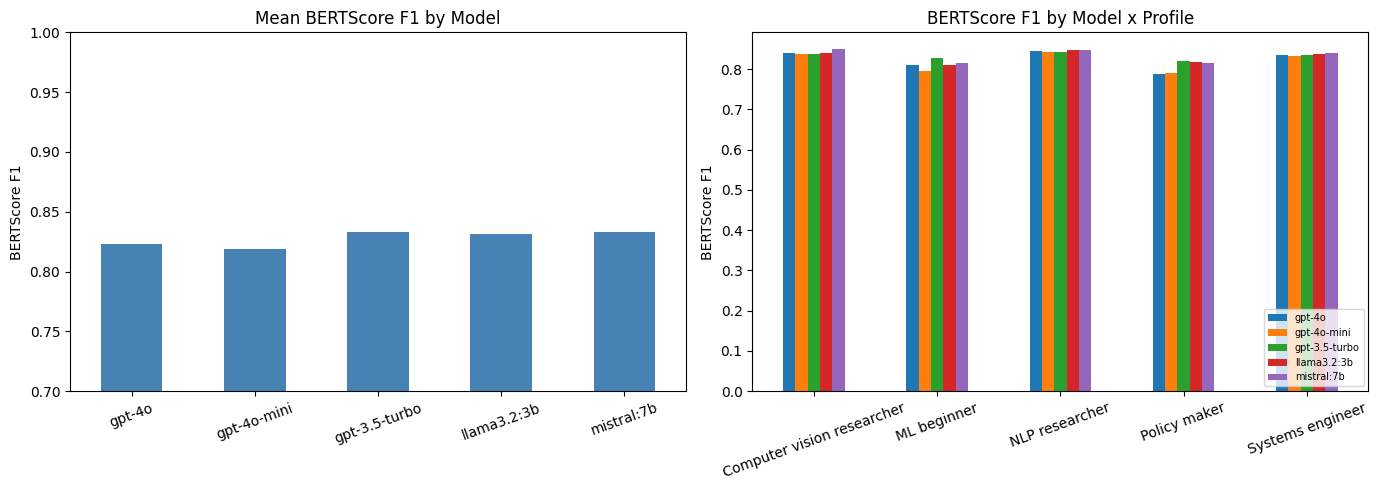

Saved results/multi_model_comparison.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: overall mean per model
means = valid_model.groupby("model")["bertscore_f1"].mean().reindex(MODELS)
means.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Mean BERTScore F1 by Model")
axes[0].set_xlabel("")
axes[0].set_ylabel("BERTScore F1")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylim(0.7, 1.0)

# right: per-profile breakdown to see if model differences vary by profile
profile_model = valid_model.pivot_table(
    values="bertscore_f1", index="profile_name", columns="model", aggfunc="mean"
)[MODELS]
profile_model.plot(kind="bar", ax=axes[1])
axes[1].set_title("BERTScore F1 by Model x Profile")
axes[1].set_xlabel("")
axes[1].set_ylabel("BERTScore F1")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(loc="lower right", fontsize=7)

plt.tight_layout()
plt.savefig("results/multi_model_comparison.png", dpi=150)
plt.show()
print("Saved results/multi_model_comparison.png")


### 6c. BERTScore — Relevant vs Irrelevant

**What:** Does forcing profile conditioning on out-of-domain papers increase hallucination?

**Groups compared:** 60 irrelevant papers (math.ST, econ.GN, q-bio.NC) x 5 profiles vs 93 relevant CS papers x 5 profiles.

**How:** BERTScore computed for both groups, then compared domain-by-domain and profile-by-profile.

**What to look for:** Lower BERTScore on irrelevant papers would support the hypothesis that forcing a profile angle onto unrelated content increases hallucination.

In [30]:
# compute BERTScore for irrelevant papers
valid_irr = irr_df[irr_df["summary"].str.len() > 0].reset_index(drop=True)

print("Computing BERTScore for irrelevant papers...")
_, _, F1_irr = bert_score(
    valid_irr["summary"].tolist(),
    valid_irr["abstract"].tolist(),
    lang="en", model_type="distilbert-base-uncased", verbose=False
)
valid_irr["bertscore_f1"] = F1_irr.tolist()
valid_irr.to_csv("results/irrelevant_evaluated.csv", index=False)

# also make sure relevant papers have bertscore_f1 — compute if not already done
if "bertscore_f1" not in df.columns:
    EVALUATED_CSV = "results/results_evaluated.csv"
    if os.path.exists(EVALUATED_CSV):
        _eval = pd.read_csv(EVALUATED_CSV)[["arxiv_id", "profile_id", "bertscore_f1"]]
        df = df.merge(_eval, on=["arxiv_id", "profile_id"], how="left")
    else:
        _valid = df[df["summary"].str.len() > 0]
        _, _, _F1 = bert_score(
            _valid["summary"].tolist(), _valid["abstract"].tolist(),
            lang="en", model_type="distilbert-base-uncased", verbose=False
        )
        df.loc[df["summary"].str.len() > 0, "bertscore_f1"] = _F1.tolist()


Computing BERTScore for irrelevant papers...


In [31]:
# combine relevant and irrelevant into one dataframe for comparison
valid_df_copy = df[df["summary"].str.len() > 0].copy()
valid_df_copy["domain"] = "relevant"
valid_irr["domain"]     = "irrelevant"

combined = pd.concat([
    valid_df_copy[["profile_name", "bertscore_f1", "domain"]],
    valid_irr[["profile_name",    "bertscore_f1", "domain"]]
], ignore_index=True)

print("Relevant vs Irrelevant papers (BERTScore):")
print(combined.groupby("domain")["bertscore_f1"].agg(["mean","std"]).round(4))

print("\nBy profile x domain:")
print(combined.pivot_table(
    values="bertscore_f1", index="profile_name",
    columns="domain", aggfunc="mean"
).round(4))


Relevant vs Irrelevant papers (BERTScore):
              mean     std
domain                    
irrelevant  0.8245  0.0330
relevant    0.8262  0.0331

By profile x domain:
domain                      irrelevant  relevant
profile_name                                    
Computer vision researcher      0.8415    0.8423
ML beginner                     0.8050    0.8040
NLP researcher                  0.8480    0.8488
Policy maker                    0.7937    0.7983
Systems engineer                0.8342    0.8376


C:\Users\baodu\AppData\Local\Temp\ipykernel_43320\3923033575.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x="domain", y="bertscore_f1",


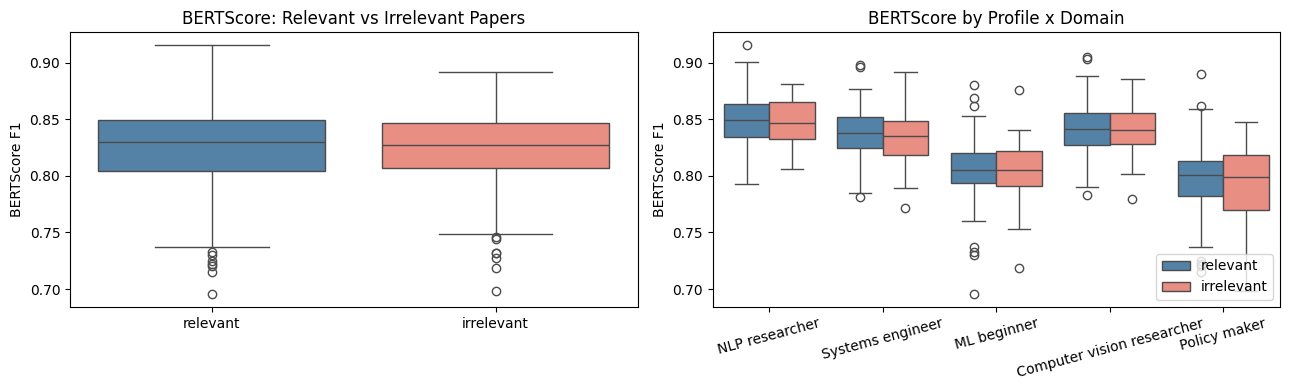

Saved results/relevant_vs_irrelevant.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: overall domain comparison
sns.boxplot(data=combined, x="domain", y="bertscore_f1",
            palette={"relevant": "steelblue", "irrelevant": "salmon"}, ax=axes[0])
axes[0].set_title("BERTScore: Relevant vs Irrelevant Papers")
axes[0].set_ylabel("BERTScore F1")
axes[0].set_xlabel("")

# right: per-profile breakdown to see if some profiles are more affected
sns.boxplot(data=combined, x="profile_name", y="bertscore_f1",
            hue="domain", palette={"relevant": "steelblue", "irrelevant": "salmon"},
            ax=axes[1])
axes[1].set_title("BERTScore by Profile x Domain")
axes[1].set_ylabel("BERTScore F1")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("results/relevant_vs_irrelevant.png", dpi=150)
plt.show()
print("Saved results/relevant_vs_irrelevant.png")


### 6d. AlignScore — Factual Consistency

**What:** AlignScore measures factual consistency using NLI -- does the summary only claim things that the abstract actually supports?

**Four sub-analyses:**
- **Conditioned vs baseline:** is personalization causing factual drift?
- **By prompt level:** does aggressive prompting increase factual errors?
- **By model:** do some models handle the tradeoff better than others?
- **By domain relevance:** do out-of-domain papers get less faithful summaries?

**What to look for:** A meaningful drop from baseline to conditioned, and a further drop from mild to aggressive, would be the core finding of this project.

In [33]:
# Use the AlignScore ckpt. This can be found on github
import importlib, subprocess, urllib.request

CKPT = "AlignScore/AlignScore-base.ckpt"

if importlib.util.find_spec("alignscore") is None:
    print("Installing AlignScore...")
    if not os.path.exists("AlignScore"):
        subprocess.run(["git", "clone",
                        "https://github.com/yuh-zha/AlignScore.git"], check=True)
    subprocess.run(["pip", "install", "-e", "AlignScore"], check=True)
    import nltk
    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)
    print("AlignScore installed.")
else:
    print("AlignScore already installed.")

if not os.path.exists(CKPT):
    os.makedirs("AlignScore", exist_ok=True)
    print("Downloading AlignScore-base checkpoint (~400 MB)...")
    urllib.request.urlretrieve(
        "https://huggingface.co/yzha/AlignScore/resolve/main/AlignScore-base.ckpt",
        CKPT
    )
    print("Checkpoint downloaded.")
else:
    print(f"Checkpoint present: {CKPT}")


AlignScore already installed.
Checkpoint present: AlignScore/AlignScore-base.ckpt


In [34]:
from alignscore import AlignScore
# set the AlignScore scorer
CKPT = "AlignScore/AlignScore-base.ckpt"
scorer = AlignScore(
    model="roberta-base",
    batch_size=16,
    device="cpu",
    ckpt_path=CKPT,
    evaluation_mode="nli_sp"
)
print("AlignScore scorer ready.")


C:\Users\baodu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning_fabric\__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Lightning automatically upgraded your loaded checkpoint from v1.7.7 to v1.9.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint --file e:\Dropbox\NLP_class\Project\AlignScore\A

AlignScore scorer ready.


In [35]:
ALIGN_MAIN_CSV = "results/alignscore_conditioned.csv"
ALIGN_BASE_CSV = "results/alignscore_baseline.csv"

valid_df = df[df["summary"].str.len() > 0].reset_index(drop=True)
valid_base_df = baseline_df[baseline_df["summary"].str.len() > 0].reset_index(drop=True)

align_df = load_or_score(valid_df, scorer, ALIGN_MAIN_CSV)
align_base_df = load_or_score(valid_base_df, scorer, ALIGN_BASE_CSV)

print("Mean AlignScore by profile (conditioned):")
print(align_df.groupby("profile_name")["alignscore"].agg(["mean","std"]).round(4))
print(f"Baseline mean: {align_base_df['alignscore'].mean():.4f}")
print(f"Conditioned mean: {align_df['alignscore'].mean():.4f}")
print(f"Delta: {align_df['alignscore'].mean() - align_base_df['alignscore'].mean():.4f}")


Loaded results/alignscore_conditioned.csv
Loaded results/alignscore_baseline.csv
Mean AlignScore by profile (conditioned):
                              mean     std
profile_name                              
Computer vision researcher  0.7871  0.1710
ML beginner                 0.8160  0.1550
NLP researcher              0.8491  0.1382
Policy maker                0.6290  0.1767
Systems engineer            0.7478  0.1419
Baseline mean: 0.9496
Conditioned mean: 0.7658
Delta: -0.1838


In [36]:
# does more aggressive personalization hurt factual consistency?
align_prompt_df = load_or_score(
    prompt_df[prompt_df["summary"].str.len() > 0].reset_index(drop=True),
    scorer, "results/alignscore_prompt.csv"
)

_order = ["mild", "moderate", "aggressive"]
print("AlignScore by prompt level:")
print(align_prompt_df.groupby("prompt_level")["alignscore"]
      .agg(["mean","std"]).reindex(_order).round(4))


Loaded results/alignscore_prompt.csv
AlignScore by prompt level:
                mean     std
prompt_level                
mild          0.8548  0.1589
moderate      0.7722  0.1777
aggressive    0.5359  0.2507


In [37]:
# Compute AlignScore for different models
align_model_df = load_or_score(
    model_df[model_df["summary"].str.len() > 0].reset_index(drop=True),
    scorer, "results/alignscore_model.csv"
)

print(f"AlignScore by model ({align_model_df['arxiv_id'].nunique()} papers):")
print(align_model_df.groupby("model")["alignscore"]
      .agg(["mean","std"]).reindex(MODELS_ORDER).round(4))


Loaded results/alignscore_model.csv
AlignScore by model (30 papers):
                 mean     std
model                        
gpt-4o         0.7636  0.1943
gpt-4o-mini    0.7982  0.1643
gpt-3.5-turbo  0.7904  0.1584
llama3.2:3b    0.7449  0.1743
mistral:7b     0.7446  0.1374


In [38]:
# Compute AlignScore for relevant and irrevant paper summaries and make comparisons
align_irr_df = load_or_score(
    irr_df[irr_df["summary"].str.len() > 0].reset_index(drop=True),
    scorer, "results/alignscore_irrelevant.csv"
)

_rel = align_df.assign(domain="relevant")
_irr = align_irr_df.assign(domain="irrelevant")
_combined = pd.concat(
    [_rel[["profile_name", "alignscore", "domain"]],
     _irr[["profile_name", "alignscore", "domain"]]],
    ignore_index=True
)
n_rel = align_df["arxiv_id"].nunique()
n_irr = align_irr_df["arxiv_id"].nunique()
print(f"AlignScore — Relevant ({n_rel} papers) vs Irrelevant ({n_irr} papers):")
print(_combined.groupby("domain")["alignscore"].agg(["mean","std","count"]).round(4))


Loaded results/alignscore_irrelevant.csv
AlignScore — Relevant (93 papers) vs Irrelevant (60 papers):
              mean     std  count
domain                           
irrelevant  0.7144  0.2248    300
relevant    0.7658  0.1742    465


### 6e. Plot AlignScores by profiles, prompt levels, models, and domain

C:\Users\baodu\AppData\Local\Temp\ipykernel_43320\2377661093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=align_df, x="profile_name", y="alignscore",
C:\Users\baodu\AppData\Local\Temp\ipykernel_43320\2377661093.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=15, ha="right")
C:\Users\baodu\AppData\Local\Temp\ipykernel_43320\2377661093.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=align_prompt_df, x="prompt_level", y="alignscore",
C:\Users\baodu\AppData\Local\Temp\ipykernel_43320\2377661093.py:17: FutureWarning: 

Pa

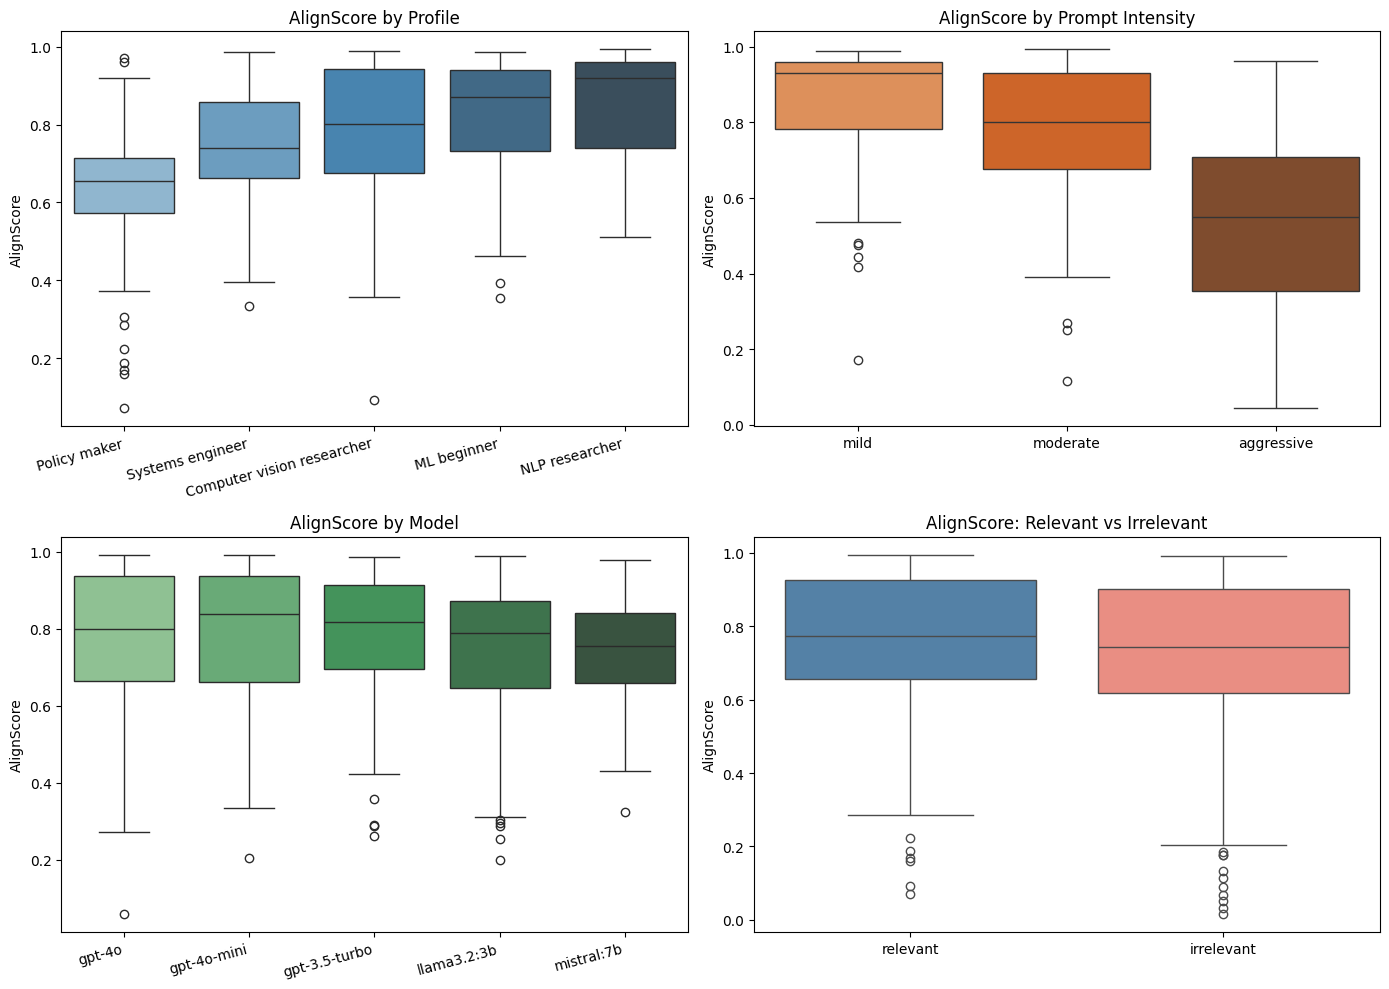

Saved results/alignscore_comparison.png


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

_prof_order = align_df.groupby("profile_name")["alignscore"].mean().sort_values().index
sns.boxplot(data=align_df, x="profile_name", y="alignscore",
            order=_prof_order, palette="Blues_d", ax=axes[0, 0])
axes[0, 0].set_title("AlignScore by Profile")
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=15, ha="right")
axes[0, 0].set_ylabel("AlignScore")
axes[0, 0].set_xlabel("")

sns.boxplot(data=align_prompt_df, x="prompt_level", y="alignscore",
            order=["mild","moderate","aggressive"], palette="Oranges_d", ax=axes[0, 1])
axes[0, 1].set_title("AlignScore by Prompt Intensity")
axes[0, 1].set_ylabel("AlignScore")
axes[0, 1].set_xlabel("")

sns.boxplot(data=align_model_df, x="model", y="alignscore",
            order=MODELS_ORDER, palette="Greens_d", ax=axes[1, 0])
axes[1, 0].set_title("AlignScore by Model")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15, ha="right")
axes[1, 0].set_ylabel("AlignScore")
axes[1, 0].set_xlabel("")

sns.boxplot(data=_combined, x="domain", y="alignscore",
            palette={"relevant":"steelblue","irrelevant":"salmon"}, ax=axes[1, 1])
axes[1, 1].set_title("AlignScore: Relevant vs Irrelevant")
axes[1, 1].set_ylabel("AlignScore")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.savefig("results/alignscore_comparison.png", dpi=150)
plt.show()
print("Saved results/alignscore_comparison.png")


> **Reference:** Zhongxiang Sun et al. (2024). *When Personalization Misleads: Understanding and Mitigating Hallucinations in Personalized LLMs.*

## 7. Save Final Results

In [40]:
# Merge AlignScore into df
if "alignscore" not in df.columns and os.path.exists("results/alignscore_conditioned.csv"):
    _as = pd.read_csv("results/alignscore_conditioned.csv")[["arxiv_id","profile_id","alignscore"]]
    df = df.merge(_as, on=["arxiv_id","profile_id"], how="left")

df.to_csv("results/results_evaluated.csv", index=False)
print("Saved results/results_evaluated.csv")
cols = [col for col in ["arxiv_id","profile_name","bertscore_f1","alignscore","summary"] if col in df.columns]
df[cols].head(5)


Saved results/results_evaluated.csv


,arxiv_id,profile_name,bertscore_f1,alignscore,summary
0,2604.25917v1,NLP researcher,0.842994,0.988910,"The paper introduces RecursiveMAS, a novel rec..."
1,2604.25917v1,Systems engineer,0.830673,0.802934,"The paper introduces RecursiveMAS, a recursive..."
2,2604.25917v1,ML beginner,0.794615,0.924127,"This paper introduces RecursiveMAS, a new fram..."
3,2604.25917v1,Computer vision researcher,0.823450,0.379337,"The paper introduces RecursiveMAS, a recursive..."
4,2604.25917v1,Policy maker,0.765284,0.662646,"This paper introduces RecursiveMAS, a novel fr..."
